In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
import statistics

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.
/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [2]:
stn_motor_HDP = nib.load("./HDP_Pos_Neg.nii")
data_HDP = stn_motor_HDP.get_fdata()
indices_HDP = np.argwhere(data_HDP > 0)
affine_HDP = stn_motor_HDP.affine

In [3]:
indices_test = np.random.choice(len(indices_HDP), size = 10000)
voxel_coords_test = indices_HDP[indices_test]
ones = np.ones((10000, 1))
vox_hom = np.hstack([voxel_coords_test, ones])          # (N,4)
world_points = (affine_HDP @ vox_hom.T).T[:, :3]

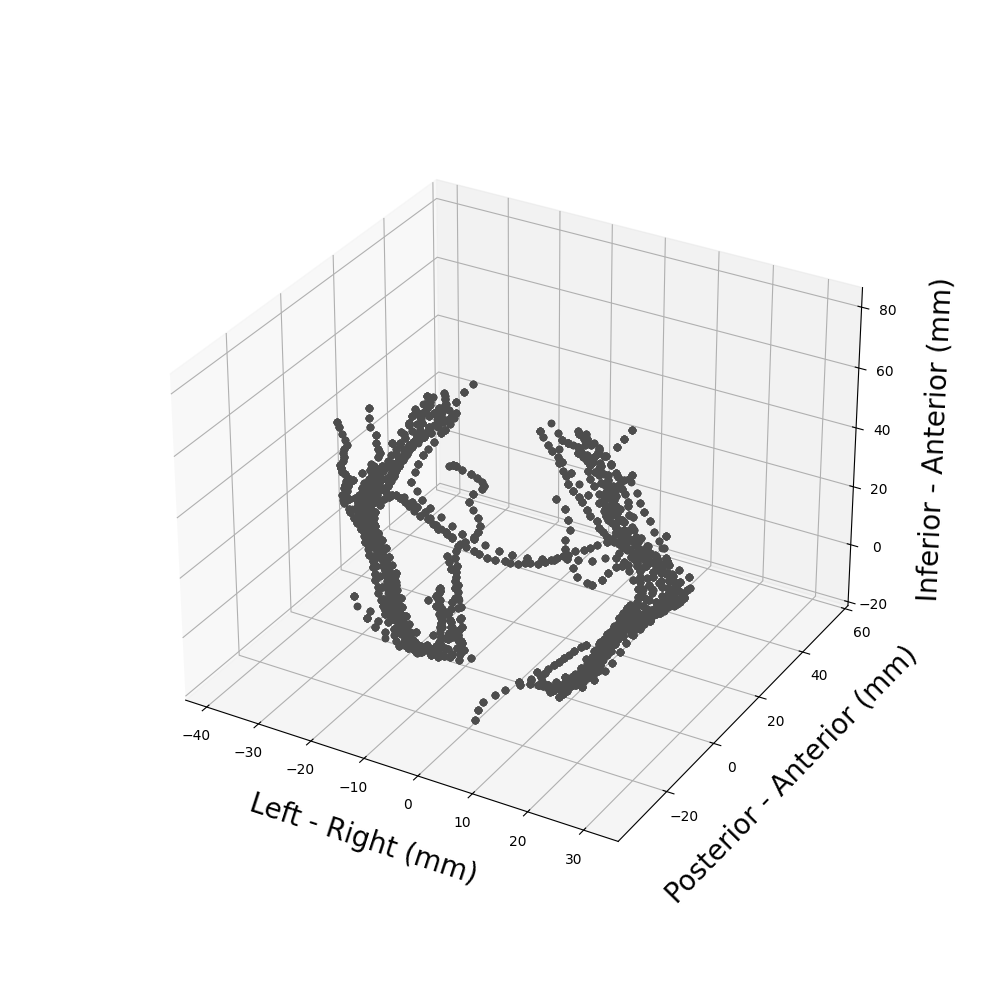

In [4]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = world_points[:,0]
y_points = world_points[:,1]
z_points = world_points[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "HDP",depthshade=False)
plt.show()

In [2]:
class LeadDBS_atlas_random_point_generator:
    def __init__(self, atlas, stimulating_electrode_position, encapsulation_radius):
        self.atlas = atlas
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius
        
        
        self.region_data = self.atlas.get_fdata()
        self.affine = self.atlas.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)        


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = (x_coordinates**2 + y_coordinates**2 > self.encapsulation_radius**2) & (x_coordinates < 0)
          

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points

In [6]:
atlas_ewert = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
atlas_HDP = nib.load("./HDP_Pos_Neg.nii")


electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_ewert = LeadDBS_atlas_random_point_generator(atlas_ewert, electrode_position_mm, encapsulation_mm)
positions_ewert = random_point_generator_ewert.generate_positions(1000)

random_point_generator_HDP = LeadDBS_atlas_random_point_generator(atlas_HDP, electrode_position_mm, encapsulation_mm)
positions_HDP = random_point_generator_HDP.generate_positions(1000)

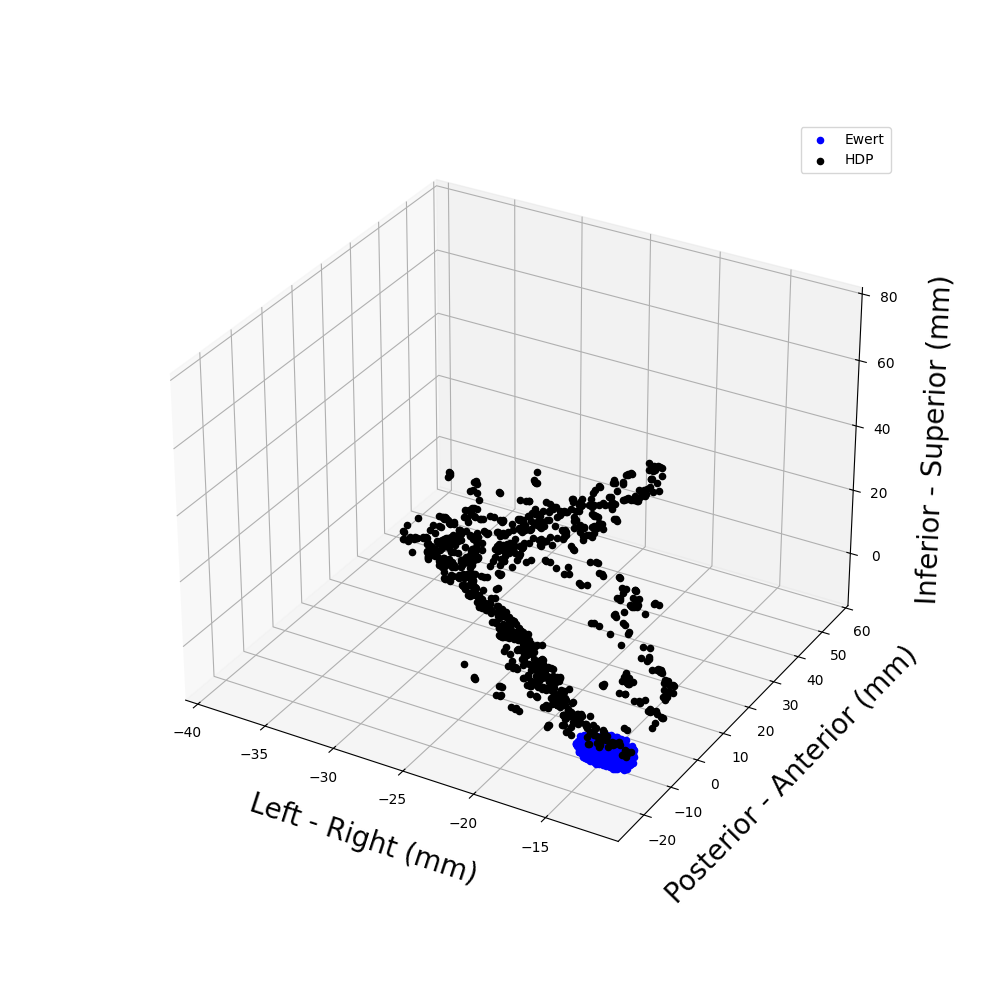

In [7]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Superior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### ewert ##############
x_points_ewert = positions_ewert[:,0]
y_points_ewert = positions_ewert[:,1]
z_points_ewert = positions_ewert[:,2]

ax.scatter(x_points_ewert, y_points_ewert, z_points_ewert, c='blue', label = "Ewert", depthshade=False)
'''
##### middle ##############
x_points_middle = positions_middle[:,0]
y_points_middle = positions_middle[:,1]
z_points_middle = positions_middle[:,2]

ax.scatter(x_points_middle, y_points_middle, z_points_middle, c='green', label = "Middlebrooks", depthshade=False)

##### Li ##############
x_points_li = positions_li[:,0]
y_points_li = positions_li[:,1]
z_points_li = positions_li[:,2]

ax.scatter(x_points_li, y_points_li, z_points_li, c='red', label = "Li", depthshade=False)

##### Accolla ##############
x_points_accolla = positions_accolla[:,0]
y_points_accolla = positions_accolla[:,1]
z_points_accolla = positions_accolla[:,2]

ax.scatter(x_points_accolla, y_points_accolla, z_points_accolla, c='orange', label = "Accolla", depthshade=False)
'''

##### HDP ##############
x_points_HDP = positions_HDP[:,0]
y_points_HDP = positions_HDP[:,1]
z_points_HDP = positions_HDP[:,2]

ax.scatter(x_points_HDP, y_points_HDP, z_points_HDP, c='black', label = "HDP", depthshade=False, alpha = 1)

#ax.axes.set_xlim3d(left=-40, right=0) 
ax.legend()

plt.show()

In [132]:
class LeadDBS_HDP_atlas_random_point_generator:
    def __init__(self, atlas):
        self.atlas = atlas
        
        
        
        self.region_data = self.atlas.get_fdata()
        self.affine = self.atlas.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)        


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] 
        y_coordinates = world_points[:, 1] 
        z_coordinates = world_points[:, 2] 


        mask = ((x_coordinates > -27.5) & (x_coordinates < -22.5) & (y_coordinates > -20) & (y_coordinates < 0) & (z_coordinates > 10) & (z_coordinates < 30))
          

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points

In [134]:
atlas_ewert = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
atlas_HDP = nib.load("./HDP_Pos_Neg.nii")


electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_ewert = LeadDBS_atlas_random_point_generator(atlas_ewert, electrode_position_mm, encapsulation_mm)
positions_ewert = random_point_generator_ewert.generate_positions(1000)

random_point_generator_HDP = LeadDBS_HDP_atlas_random_point_generator(atlas_HDP)
positions_HDP = random_point_generator_HDP.generate_positions(1000)

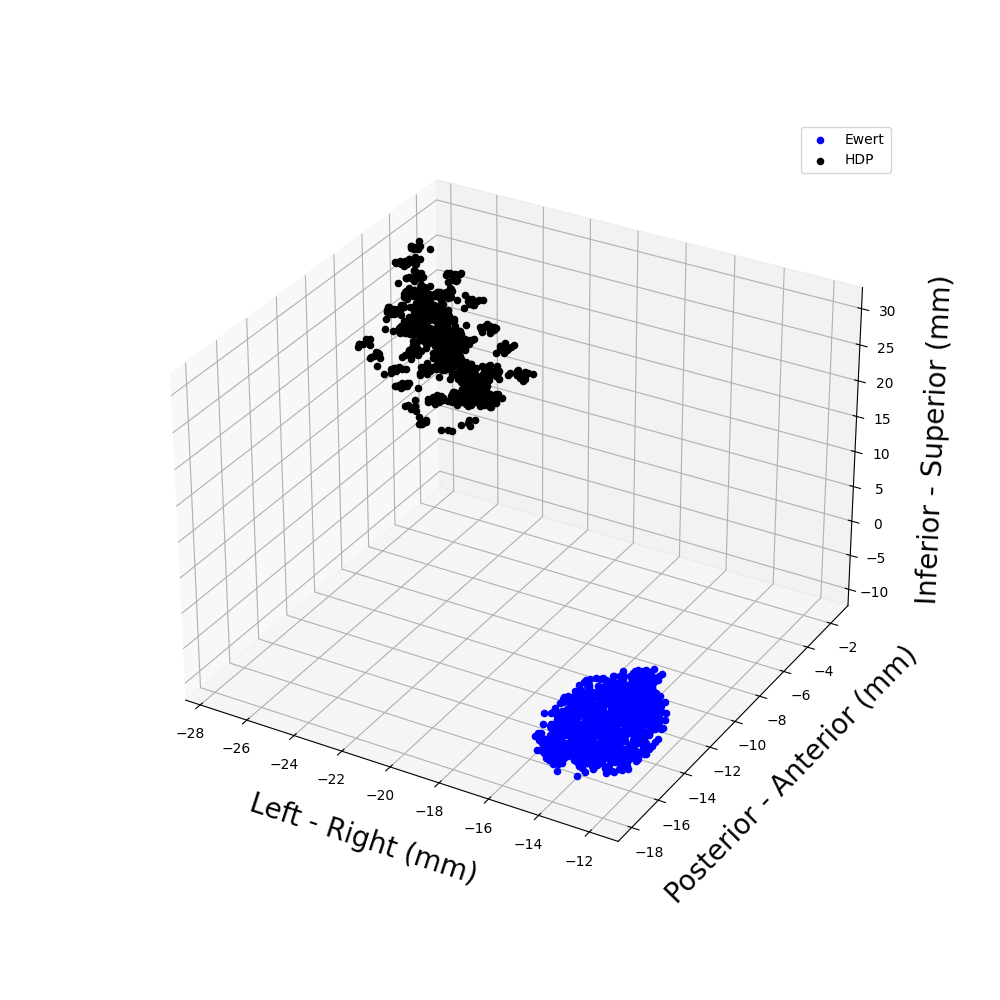

In [124]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Superior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### ewert ##############
x_points_ewert = positions_ewert[:,0]
y_points_ewert = positions_ewert[:,1]
z_points_ewert = positions_ewert[:,2]

ax.scatter(x_points_ewert, y_points_ewert, z_points_ewert, c='blue', label = "Ewert", depthshade=False)
'''
##### middle ##############
x_points_middle = positions_middle[:,0]
y_points_middle = positions_middle[:,1]
z_points_middle = positions_middle[:,2]

ax.scatter(x_points_middle, y_points_middle, z_points_middle, c='green', label = "Middlebrooks", depthshade=False)

##### Li ##############
x_points_li = positions_li[:,0]
y_points_li = positions_li[:,1]
z_points_li = positions_li[:,2]

ax.scatter(x_points_li, y_points_li, z_points_li, c='red', label = "Li", depthshade=False)

##### Accolla ##############
x_points_accolla = positions_accolla[:,0]
y_points_accolla = positions_accolla[:,1]
z_points_accolla = positions_accolla[:,2]

ax.scatter(x_points_accolla, y_points_accolla, z_points_accolla, c='orange', label = "Accolla", depthshade=False)
'''

##### HDP ##############
x_points_HDP = positions_HDP[:,0]
y_points_HDP = positions_HDP[:,1]
z_points_HDP = positions_HDP[:,2]

ax.scatter(x_points_HDP, y_points_HDP, z_points_HDP, c='black', label = "HDP", depthshade=False, alpha = 1)

#ax.axes.set_xlim3d(left=-40, right=0) 
ax.legend()

plt.show()

In [145]:
def collateral_positions_along_HDP(tgt_pop_coordinates, HDP_coordinates, n, nseg=11):

    distances = (tgt_pop_coordinates - HDP_coordinates)/nseg

    collateral_coordinates = np.zeros((n, nseg, 3))

    for cell_number in range(n):
        collateral_coordinates[cell_number, 0] = tgt_pop_coordinates[cell_number]

        for seg_number in range(1, nseg):
            collateral_coordinates[cell_number, seg_number] = tgt_pop_coordinates[cell_number] - seg_number*distances[cell_number]            
     
    return collateral_coordinates   

In [146]:
atlas_ewert = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
atlas_HDP = nib.load("./HDP_Pos_Neg.nii")


electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_ewert = LeadDBS_atlas_random_point_generator(atlas_ewert, electrode_position_mm, encapsulation_mm)
positions_ewert = random_point_generator_ewert.generate_positions(100)

random_point_generator_HDP = LeadDBS_HDP_atlas_random_point_generator(atlas_HDP)
positions_HDP = random_point_generator_HDP.generate_positions(100)

collateral_positions = collateral_positions_along_HDP(positions_ewert, positions_HDP, 100)

In [150]:
atlas_ewert = nib.load("./Motor_division_of_STN_atlases/STN_motor_DISTAL_Ewert_2017_left.nii")
atlas_HDP = nib.load("./HDP_Pos_Neg.nii")


electrode_position_mm = np.array([-12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_ewert = LeadDBS_atlas_random_point_generator(atlas_ewert, electrode_position_mm, encapsulation_mm)
positions_ewert = random_point_generator_ewert.generate_positions(1000)

random_point_generator_HDP = LeadDBS_HDP_atlas_random_point_generator(atlas_HDP)
positions_HDP = random_point_generator_HDP.generate_positions(1000)

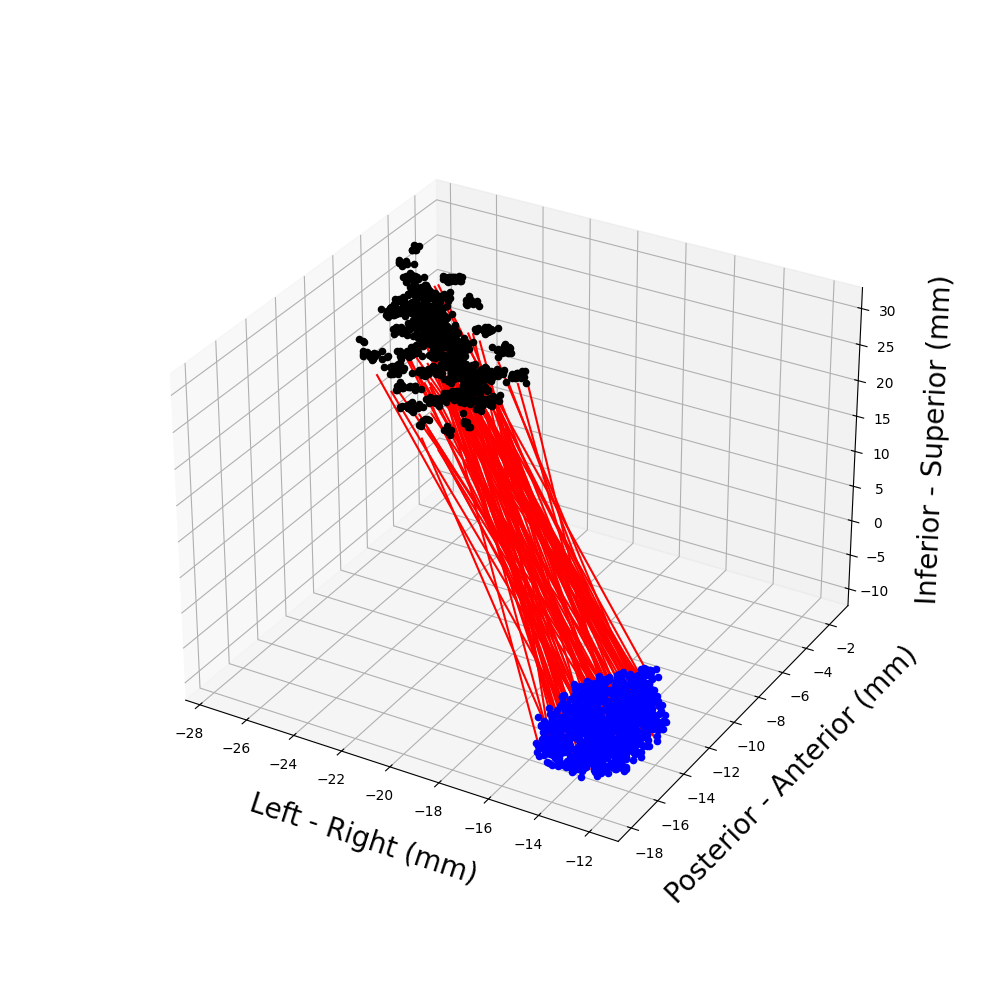

In [154]:
%matplotlib widget


##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Superior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### ewert ##############
x_points_ewert = positions_ewert[:,0]
y_points_ewert = positions_ewert[:,1]
z_points_ewert = positions_ewert[:,2]

ax.scatter(x_points_ewert, y_points_ewert, z_points_ewert, c='blue', label = "Ewert", depthshade=False)

##### HDP ##############
x_points_HDP = positions_HDP[:,0]
y_points_HDP = positions_HDP[:,1]
z_points_HDP = positions_HDP[:,2]

ax.scatter(x_points_HDP, y_points_HDP, z_points_HDP, c='black', label = "HDP", depthshade=False, alpha = 1)

for i in range(0, n):
    x_points_collateral = collateral_positions[:,:,0][i]
    y_points_collateral = collateral_positions[:,:,1][i]
    z_points_collateral = collateral_positions[:,:,2][i]
    ax.plot(x_points_collateral, y_points_collateral, z_points_collateral, c='red', label = "collaterals")

#ax.axes.set_xlim3d(left=-40, right=0) 
#ax.legend()

plt.show()